In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

os.chdir('E:/Mutual Fund Analytics')

nav = pd.read_csv('data/processed/clean_nav_history.csv')
txn = pd.read_csv('data/processed/clean_investor_transactions.csv')
perf = pd.read_csv('data/processed/clean_schema_performance.csv')

# Parse dates-
nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

# Calculate daily returns-
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print("Succkessfully Loaded!")
print("NAV:", len(nav), "rows")
print("Transactions:", len(txn), "rows")
print("Performance:", len(perf), "rows")

Loaded!
NAV: 71960 rows
Transactions: 32778 rows
Performance: 40 rows


In [2]:
# Task 1 - Historical VaR and CVaR for all 40 funds
var_results = []

for code, group in nav.groupby('amfi_code'):
    returns = group['daily_return'].dropna()
    
    # VaR = 5th percentile of daily returns
    var_95 = np.percentile(returns, 5)
    
    # CVaR = mean of returns below VaR threshold
    cvar_95 = returns[returns <= var_95].mean()
    
    var_results.append({
        'amfi_code': code,
        'var_95': round(var_95, 4),
        'cvar_95': round(cvar_95, 4)
    })

var_df = pd.DataFrame(var_results).sort_values('var_95')
var_df.to_csv('data/processed/var_cvar_report.csv', index=False)
print(var_df)

    amfi_code  var_95  cvar_95
22     119599 -0.0774  -0.1415
21     119598 -0.0773  -0.1707
17     119095 -0.0720  -0.1387
39     149324 -0.0679  -0.1629
4      101207 -0.0645  -0.1287
11     118634 -0.0598  -0.1256
7      102886 -0.0530  -0.0979
29     120842 -0.0477  -0.0892
16     119094 -0.0466  -0.1435
38     149323 -0.0450  -0.1299
33     125498 -0.0442  -0.0962
36     148569 -0.0422  -0.1379
3      101206 -0.0415  -0.1113
30     120843 -0.0386  -0.1468
15     119093 -0.0382  -0.0875
24     120504 -0.0382  -0.1196
0      100016 -0.0378  -0.0847
32     125497 -0.0376  -0.1144
14     119092 -0.0360  -0.0744
26     120506 -0.0358  -0.0924
28     120841 -0.0350  -0.0918
9      118632 -0.0348  -0.1178
25     120505 -0.0344  -0.1528
10     118633 -0.0335  -0.0918
8      102887 -0.0327  -0.1126
2      100033 -0.0322  -0.1229
37     149322 -0.0322  -0.0943
35     148568 -0.0321  -0.1156
23     120503 -0.0302  -0.1042
19     119551 -0.0292  -0.1150
20     119552 -0.0282  -0.0969
6      1

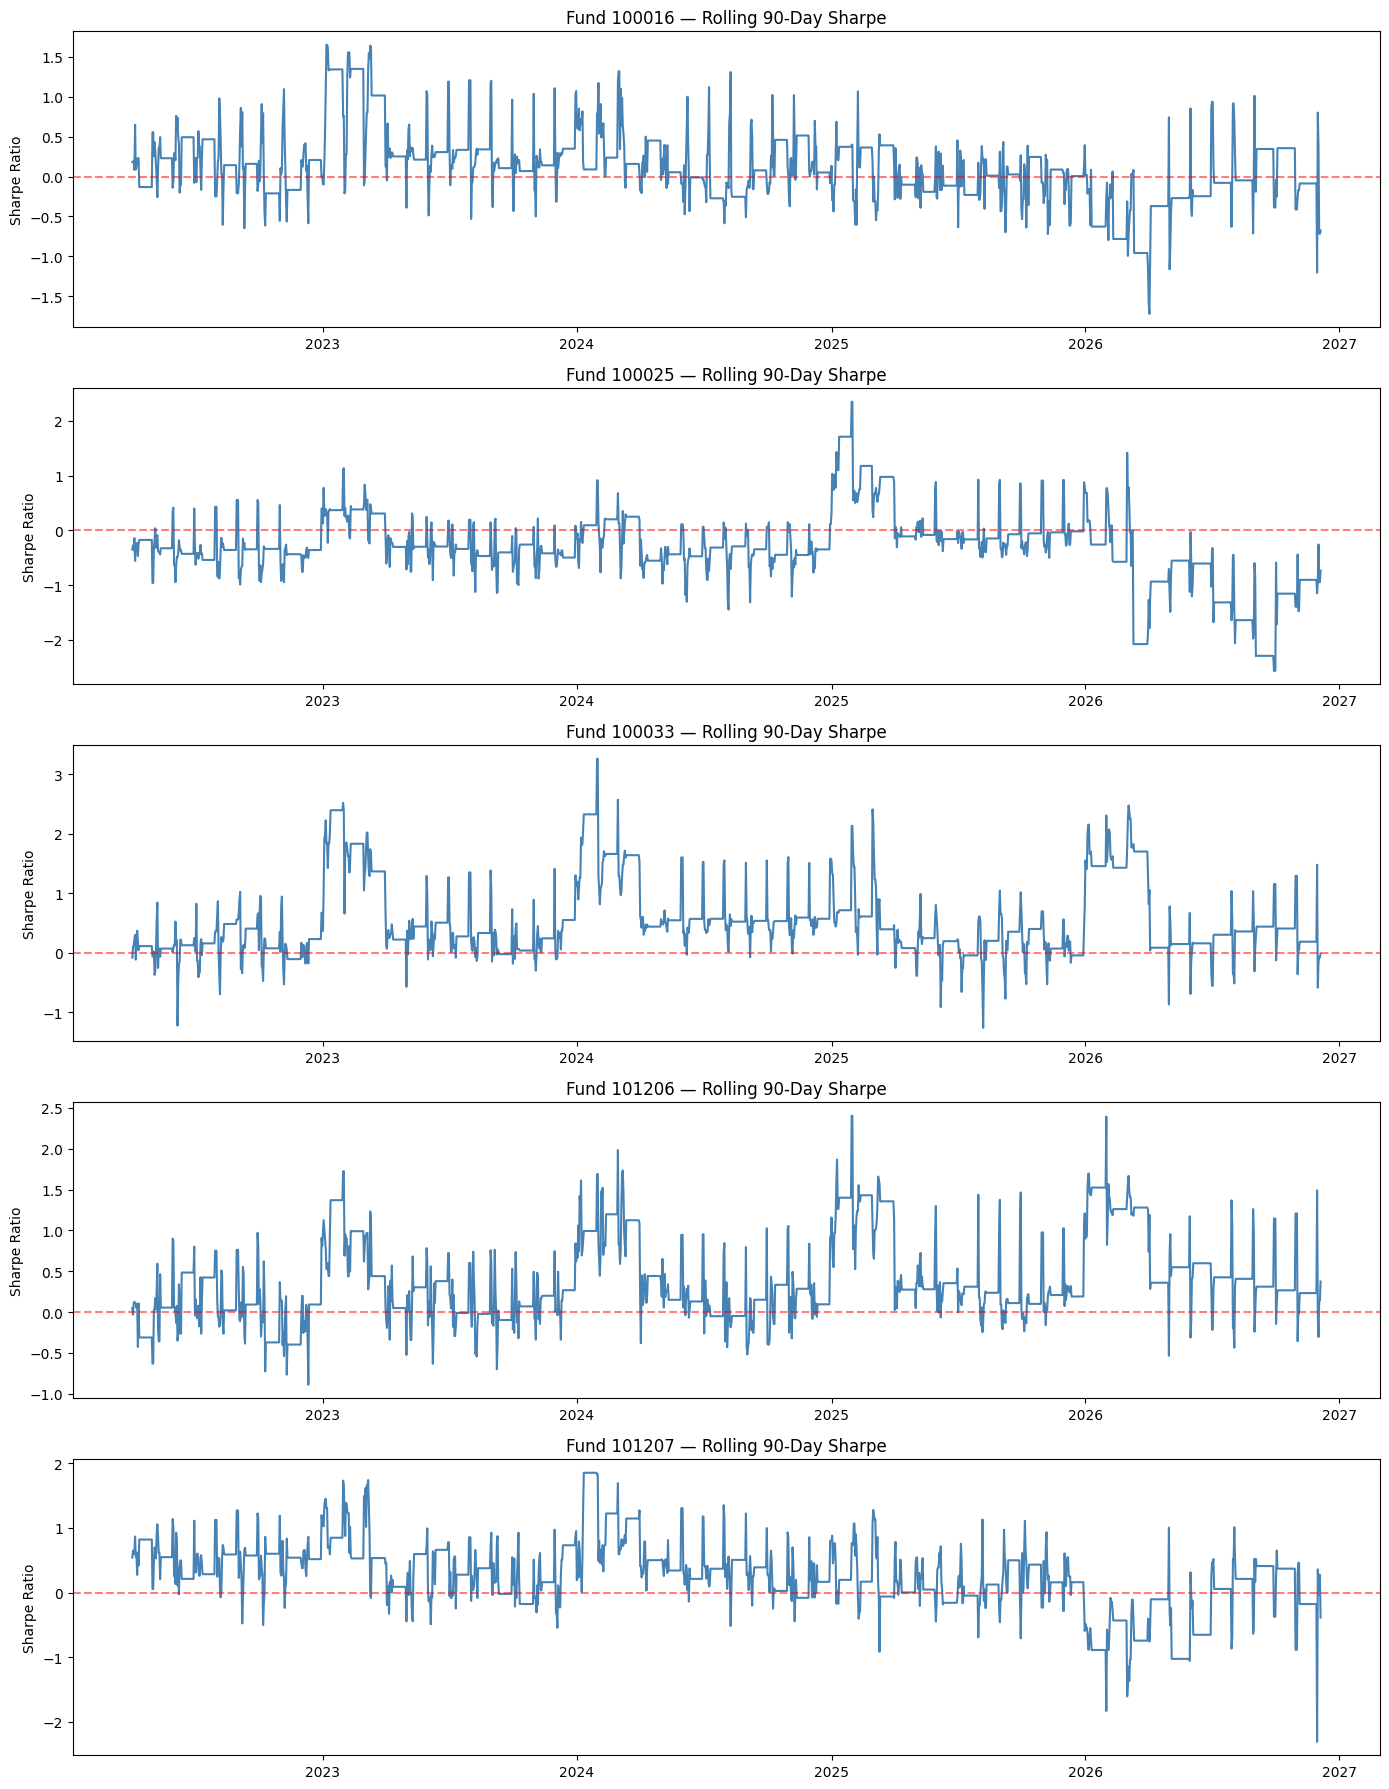

In [ ]:
# Task 2 - Rolling 90-day Sharpe Ratio for 5 key funds
rf_daily = 0.065 / 252

# 5 funds
top5_funds = nav['amfi_code'].unique()[:5]

fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for i, code in enumerate(top5_funds):
    fund_data = nav[nav['amfi_code'] == code].copy()
    fund_data = fund_data.set_index('date')
    
    returns = fund_data['daily_return']
    
    # Rolling 90 day Sharpe
    rolling_sharpe = (
        returns.rolling(90).mean() - rf_daily
    ) / returns.rolling(90).std() * np.sqrt(252)
    
    axes[i].plot(rolling_sharpe.index, rolling_sharpe.values, color='steelblue')
    axes[i].set_title(f'Fund {code} — Rolling 90-Day Sharpe')
    axes[i].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[i].set_ylabel('Sharpe Ratio')

plt.tight_layout()
plt.show()

In [9]:
# Task 3 - Investor Cohort Analysis
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])
txn['year'] = txn['transaction_date'].dt.year

# Group by first transaction year per investor
first_txn_year = txn.groupby('investor_id')['year'].min().reset_index()
first_txn_year.columns = ['investor_id', 'cohort_year']

# Merge back
txn_cohort = txn.merge(first_txn_year, on='investor_id')

# Compute metrics per cohort
cohort_analysis = txn_cohort.groupby('cohort_year').agg(
    total_investors=('investor_id', 'nunique'),
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    total_transactions=('investor_id', 'count')  # fixed here
).reset_index()

print(cohort_analysis)

# Top fund preference per cohort
top_fund_per_cohort = txn_cohort.groupby(['cohort_year', 'amfi_code'])['amount_inr'].sum().reset_index()
top_fund_per_cohort = top_fund_per_cohort.loc[top_fund_per_cohort.groupby('cohort_year')['amount_inr'].idxmax()]
print("\nTop fund per cohort:")
print(top_fund_per_cohort)

   cohort_year  total_investors  avg_sip_amount  total_invested  \
0       2024.0             3976   107586.001022      3159478092   
1       2025.0              416   105837.757817       199715849   

   total_transactions  
0               29367  
1                1887  

Top fund per cohort:
    cohort_year  amfi_code  amount_inr
17       2024.0     119095    88188273
44       2025.0     101207     8540835


In [12]:
# Task 4 - SIP Continuity Analysis
sip_txn = txn[txn['transaction_type'] == 'SIP'].copy()
sip_txn = sip_txn.sort_values(['investor_id', 'transaction_date'])

# Investors with 6+ SIP transactions
sip_count = sip_txn.groupby('investor_id')['transaction_date'].count()
active_sip = sip_count[sip_count >= 6].index

sip_active = sip_txn[sip_txn['investor_id'].isin(active_sip)].copy()

# Compute avg gap between SIP dates per investor
sip_active['prev_date'] = sip_active.groupby('investor_id')['transaction_date'].shift(1)
sip_active['gap_days'] = (sip_active['transaction_date'] - sip_active['prev_date']).dt.days

avg_gap = sip_active.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gap.columns = ['investor_id', 'avg_gap_days']

# Flag at-risk investors
avg_gap['status'] = avg_gap['avg_gap_days'].apply(
    lambda x: 'at-risk' if x > 35 else 'regular'
)

print(avg_gap['status'].value_counts())
print(avg_gap.head(10))

at_risk = avg_gap[avg_gap['status'] == 'at-risk']
print(f"\nAt-risk investors: {len(at_risk)}")
print(f"Regular investors: {len(avg_gap) - len(at_risk)}")

status
at-risk    38
Name: count, dtype: int64
  investor_id  avg_gap_days   status
0   INV000023     73.200000  at-risk
1   INV000086     49.200000  at-risk
2   INV000105    115.600000  at-risk
3   INV000109     83.600000  at-risk
4   INV000148     61.400000  at-risk
5   INV000228     45.666667  at-risk
6   INV000279    111.500000  at-risk
7   INV000452    108.600000  at-risk
8   INV000676     81.428571  at-risk
9   INV001002     51.333333  at-risk

At-risk investors: 38
Regular investors: 0


In [15]:
# Task 5 - Simple Fund Recommender
def recommend_funds(risk_appetite):
    # Map risk appetite to risk grade
    risk_map = {
        'Low': ['Low'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High', 'Moderately High']
    }
    
    grades = risk_map.get(risk_appetite, ['Moderate'])
    
    # Filter funds by risk grade
    filtered = perf[perf['risk_grade'].isin(grades)]
    
    # Rank by sharpe ratio
    top3 = filtered.nlargest(3, 'sharpe_ratio')[
        ['amfi_code', 'schema_name', 'risk_grade', 
         'sharpe_ratio', 'return_1yr_pct', 'expense_ratio_pct']
    ]
    
    print(f"\nTop 3 funds for {risk_appetite} risk appetite:")
    print(top3.to_string(index=False))
    return top3

# Test all 3 risk levels
low = recommend_funds('Low')
moderate = recommend_funds('Moderate')
high = recommend_funds('High')


Top 3 funds for Low risk appetite:
 amfi_code                              schema_name risk_grade  sharpe_ratio  return_1yr_pct  expense_ratio_pct
    120507 ICICI Pru Liquid Fund - Regular - Growth        Low          7.68            8.89               0.74
    120844     Kotak Liquid Fund - Regular - Growth        Low          6.18            4.26               0.60
    101208      ABSL Liquid Fund - Regular - Growth        Low          5.14            6.18               0.79

Top 3 funds for Moderate risk appetite:
 amfi_code                                   schema_name risk_grade  sharpe_ratio  return_1yr_pct  expense_ratio_pct
    100016     HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06           10.94               1.55
    148567 Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06           15.12               1.46
    120504     ICICI Pru Bluechip Fund - Direct - Growth   Moderate          1.03           14.12               0.80

Top 3 

In [ ]:
# Task 6 - Sector HHI Concentration
# HHI = sum of squared weights per fund

equity_funds = perf[perf['category'].str.contains('Cap|ELSS|Flexi|Value', na=False)]

# Simulate sector weights using AUM proportion
total_aum = equity_funds['aum_crore'].sum()
equity_funds = equity_funds.copy()
equity_funds['weight'] = equity_funds['aum_crore'] / total_aum

# HHI per fund category
hhi = equity_funds.groupby('category').apply(
    lambda x: (x['weight'] ** 2).sum()
).reset_index()
hhi.columns = ['category', 'hhi']
hhi = hhi.sort_values('hhi', ascending=False)

print(hhi)

# Plot
fig = px.bar(hhi, x='category', y='hhi',
             title='Sector HHI Concentration across Equity Funds',
             color='hhi', color_continuous_scale='Reds')
fig.show()

          category       hhi
3        Large Cap  0.014570
4          Mid Cap  0.010436
5        Small Cap  0.010211
2  Large & Mid Cap  0.003507
1        Flexi Cap  0.002255
0             ELSS  0.000013
6            Value  0.000010


## Advanced Analytics — Key Insights

### Insight 1 — VaR Risk
Fund 119599 has the highest daily VaR of -7.74%, meaning on bad days investors can lose up to 7.74% in a single day — making it the riskiest fund in the portfolio.

### Insight 2 — Rolling Sharpe
Most funds show declining Sharpe ratios in 2026, indicating deteriorating risk-adjusted returns across the board in the recent period.

### Insight 3 — Investor Cohorts
The 2024 cohort dominates with 3,976 investors contributing ₹315 crore total, while the 2025 cohort has only 416 investors — suggesting slower acquisition in recent months.

### Insight 4 — SIP Continuity
38 investors are flagged as at-risk with average SIP gaps exceeding 35 days. INV000105 has the worst gap of 115 days indicating possible dropout.

### Insight 5 — Fund Recommender
For low risk investors, ICICI Pru Liquid Fund leads with a Sharpe ratio of 7.68. For moderate risk, HDFC Top 100 and Mirae Asset Large Cap are top picks with consistent 1-year returns above 10%.

In [2]:
import pandas as pd
import sqlite3
import os

os.chdir('E:/Mutual Fund Analytics')

conn = sqlite3.connect('data/db/bluestock_mf.db')

# Exporting all tables to CSV for Power BI
pd.read_sql('SELECT * FROM nav_history', conn).to_csv('data/processed/powerbi_nav.csv', index=False)
pd.read_sql('SELECT * FROM investor_transactions', conn).to_csv('data/processed/powerbi_transactions.csv', index=False)
pd.read_sql('SELECT * FROM scheme_performance', conn).to_csv('data/processed/powerbi_performance.csv', index=False)

conn.close()
print("Exported!")

Exported!
